# Self-Consistency Experiments: test_set_2025_11_26

This notebook runs self-consistency analysis on the validated test set using the bedrock/openai.gpt-oss-120b-1:0 model.

**Self-consistency** measures how reliably an LLM produces the same answer when given identical inputs at `temperature=1.0`.

## Workflow
1. **Export** - Download LLM calls from production (with render_context)
2. **Sample** - Randomly sample N cases per call type
3. **Run** - Execute 5 self-consistency runs per call type
4. **Analyze** - Calculate Fleiss' kappa and consistency metrics
5. **Investigate** - Examine disagreement cases

## 1. Setup & Configuration

In [1]:
import json
import random
import subprocess
from pathlib import Path
from collections import Counter, defaultdict
from datetime import datetime
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Notebook configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

# Experiment configuration
TEST_SET_TAG = 'test_set_2025_11_26'
SAMPLE_SIZE = 100
RANDOM_SEED = 42
NUM_RUNS = 5
TEMPERATURE = 1.0
MODEL = 'bedrock/openai.gpt-oss-120b-1:0'

CALL_TYPES = [
    'instrument_validation',
    'wavelength_normalization',
    'physobs_normalization',
    'mission_selection',
    'instrument_selection',
    'detector_normalization',
    'time_normalization',
    'cadence_normalization',
    'mission_identification',
]

# Paths
INPUT_DIR = Path('../../inputs/test_set')
CONFIG_DIR = Path('experiment_configs/test_set_2025_11_26')
OUTPUT_DIR = Path('prompt_experiments')

print(f"Test Set: {TEST_SET_TAG}")
print(f"Sample Size: {SAMPLE_SIZE}")
print(f"Random Seed: {RANDOM_SEED}")
print(f"Num Runs: {NUM_RUNS}")
print(f"Model: {MODEL}")
print(f"Call Types: {len(CALL_TYPES)}")

Test Set: test_set_2025_11_26
Sample Size: 100
Random Seed: 42
Num Runs: 5
Model: bedrock/openai.gpt-oss-120b-1:0
Call Types: 9


## 2. Data Export from Production

Download ALL LLM calls from production that match:
- Paper tags: `test_set_2025_11_26`
- Have `render_context` (for re-running with same prompt)
- Each call type separately

In [2]:
# Check which files already exist
def check_exported_files():
    """Check which call types have already been exported."""
    status = {}
    for call_type in CALL_TYPES:
        file_path = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}.jsonl"
        if file_path.exists():
            with open(file_path) as f:
                count = sum(1 for _ in f)
            status[call_type] = {'exists': True, 'count': count}
        else:
            status[call_type] = {'exists': False, 'count': 0}
    return status

status = check_exported_files()
df_status = pd.DataFrame(status).T
print("\nCurrent Export Status:")
print(df_status)

missing = [ct for ct, s in status.items() if not s['exists']]
if missing:
    print(f"\n⚠️  Missing {len(missing)} call types: {missing}")
else:
    print("\n✅ All call types exported!")


Current Export Status:
                         exists count
instrument_validation      True   382
wavelength_normalization   True   293
physobs_normalization      True   186
mission_selection          True   472
instrument_selection       True   381
detector_normalization     True   190
time_normalization         True   666
cadence_normalization      True   314
mission_identification     True   778

✅ All call types exported!


In [3]:
# Run export script if needed
if missing:
    print("Running export script...")
    print("This will download ALL LLM calls from production (no limit)\n")
    
    !cd ../.. && ./scripts/export_test_set_for_self_consistency.sh
    
    # Re-check status
    status = check_exported_files()
    df_status = pd.DataFrame(status).T
    print("\nUpdated Export Status:")
    print(df_status)
else:
    print("✅ All files already exported. Skipping download.")

✅ All files already exported. Skipping download.


## 3. Data Inspection & Sampling

Examine the full dataset before sampling.

In [4]:
# Load and inspect all exported data
def load_jsonl(file_path):
    """Load JSONL file into list of dicts."""
    with open(file_path) as f:
        return [json.loads(line) for line in f]

# Load all data
all_data = {}
for call_type in CALL_TYPES:
    file_path = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}.jsonl"
    if file_path.exists():
        all_data[call_type] = load_jsonl(file_path)

# Create summary DataFrame
summary_data = []
for call_type, records in all_data.items():
    if records:
        # Extract metadata
        unique_papers = len(set(r.get('paper_bibcodes', [None])[0] for r in records if r.get('paper_bibcodes')))
        models = set(r.get('model_name') for r in records)
        has_render_context = sum(1 for r in records if r.get('render_context'))
        
        summary_data.append({
            'call_type': call_type,
            'total_records': len(records),
            'unique_papers': unique_papers,
            'with_render_context': has_render_context,
            'models': ', '.join(models) if models else 'N/A'
        })

df_summary = pd.DataFrame(summary_data)
print("\n" + "="*80)
print("EXPORTED DATA SUMMARY")
print("="*80)
print(df_summary.to_string(index=False))
print(f"\nTotal records across all call types: {df_summary['total_records'].sum()}")


EXPORTED DATA SUMMARY
               call_type  total_records  unique_papers  with_render_context            models
   instrument_validation            382             81                  382      openai/gpt-5
wavelength_normalization            293             55                  293      openai/gpt-5
   physobs_normalization            186             45                  186      openai/gpt-5
       mission_selection            472             88                  472      openai/gpt-5
    instrument_selection            381             86                  381      openai/gpt-5
  detector_normalization            190             32                  190      openai/gpt-5
      time_normalization            666             76                  666      openai/gpt-5
   cadence_normalization            314             32                  314      openai/gpt-5
  mission_identification            778             93                  778 openai/gpt-5-mini

Total records across all call types:

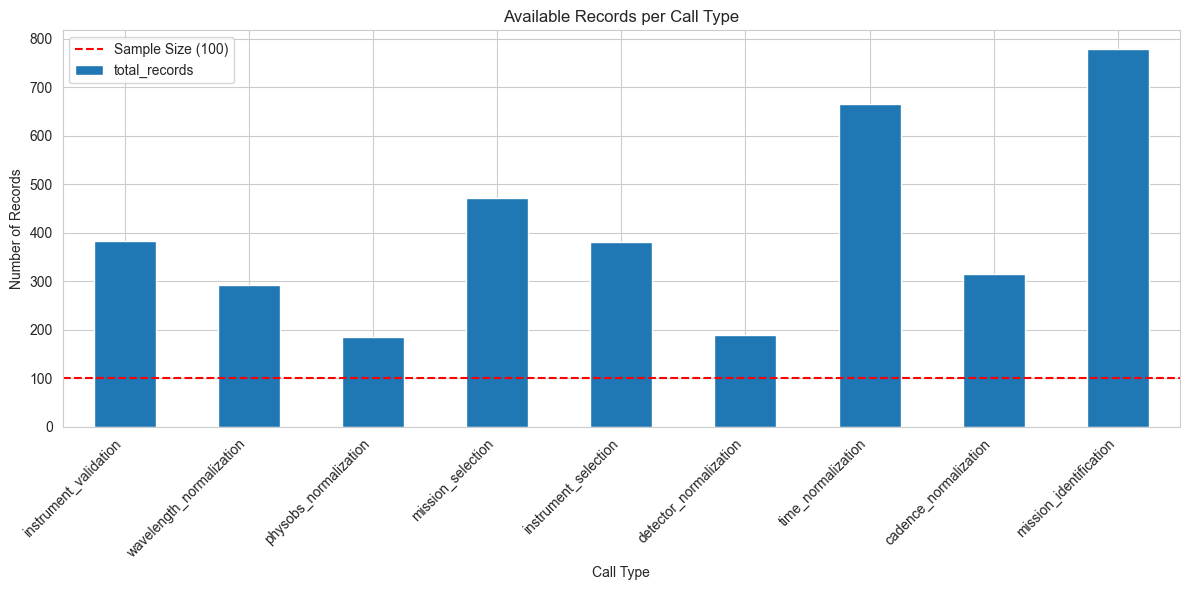

In [5]:
# Visualize record counts
fig, ax = plt.subplots(figsize=(12, 6))
df_summary.plot(x='call_type', y='total_records', kind='bar', ax=ax, legend=False)
ax.axhline(y=SAMPLE_SIZE, color='r', linestyle='--', label=f'Sample Size ({SAMPLE_SIZE})')
ax.set_title('Available Records per Call Type')
ax.set_xlabel('Call Type')
ax.set_ylabel('Number of Records')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [6]:
# Sample N records per call type
def sample_records(records, n, seed=None):
    """Sample n records randomly."""
    if len(records) <= n:
        return records
    
    if seed is not None:
        random.seed(seed)
    
    return random.sample(records, n)

# Sample and save to separate files (preserve originals!)
sampled_data = {}
for call_type, records in all_data.items():
    sampled = sample_records(records, SAMPLE_SIZE, RANDOM_SEED)
    sampled_data[call_type] = sampled
    
    # Save sampled data to separate file with sample size and seed in filename
    # This preserves the full export and allows re-sampling without re-downloading
    output_file = INPUT_DIR / f"{call_type}_{TEST_SET_TAG}_sampled_{SAMPLE_SIZE}_seed{RANDOM_SEED}.jsonl"
    with open(output_file, 'w') as f:
        for record in sampled:
            f.write(json.dumps(record) + '\n')
    
    print(f"{call_type}: Sampled {len(sampled)} from {len(records)} records → {output_file.name}")

print(f"\n✅ Sampled {SAMPLE_SIZE} records per call type (seed={RANDOM_SEED})")
print(f"✅ Full exports preserved in: {INPUT_DIR}")
print(f"Total sampled records: {sum(len(s) for s in sampled_data.values())}")

instrument_validation: Sampled 100 from 382 records → instrument_validation_test_set_2025_11_26_sampled_100_seed42.jsonl
wavelength_normalization: Sampled 100 from 293 records → wavelength_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
physobs_normalization: Sampled 100 from 186 records → physobs_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
mission_selection: Sampled 100 from 472 records → mission_selection_test_set_2025_11_26_sampled_100_seed42.jsonl
instrument_selection: Sampled 100 from 381 records → instrument_selection_test_set_2025_11_26_sampled_100_seed42.jsonl
detector_normalization: Sampled 100 from 190 records → detector_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
time_normalization: Sampled 100 from 666 records → time_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
cadence_normalization: Sampled 100 from 314 records → cadence_normalization_test_set_2025_11_26_sampled_100_seed42.jsonl
mission_identification: Sampled 100 from

## 4. Run Self-Consistency Experiments

Execute 5 runs for each call type at temperature=1.0.

In [7]:
# Check which experiments have already been run
def check_experiment_status():
    """Check which experiments have been completed."""
    status = {}
    for call_type in CALL_TYPES:
        runs_found = []
        for run in range(1, NUM_RUNS + 1):
            exp_name = f"{call_type}_{TEST_SET_TAG}_run{run}"
            exp_dir = OUTPUT_DIR / exp_name
            if exp_dir.exists():
                # Check if results file exists
                jsonl_files = list(exp_dir.glob('*.jsonl'))
                if jsonl_files:
                    runs_found.append(run)
        
        status[call_type] = {
            'completed_runs': len(runs_found),
            'runs': runs_found
        }
    return status

exp_status = check_experiment_status()
df_exp = pd.DataFrame(exp_status).T
print("\nExperiment Status:")
print(df_exp)

incomplete = [ct for ct, s in exp_status.items() if s['completed_runs'] < NUM_RUNS]
if incomplete:
    print(f"\n⚠️  {len(incomplete)} call types need experiments run")
else:
    print(f"\n✅ All {len(CALL_TYPES)} call types have {NUM_RUNS} runs completed!")


Experiment Status:
                         completed_runs runs
instrument_validation                 0   []
wavelength_normalization              0   []
physobs_normalization                 0   []
mission_selection                     0   []
instrument_selection                  0   []
detector_normalization                0   []
time_normalization                    0   []
cadence_normalization                 0   []
mission_identification                0   []

⚠️  9 call types need experiments run


### AWS Credentials Check

Before running experiments, ensure AWS credentials are fresh (Bedrock requires valid SSO session).

In [ ]:
import sys
sys.path.insert(0, '/Users/abuonomo/code/nasa/paper-data-linking')

# from paper_data_linking.config.settings import get_settings

# settings = get_settings()

# Try a minimal Bedrock API call
try:
    from litellm import completion

    print("🔍 Testing Bedrock credentials...")

    response = completion(
        model="bedrock/openai.gpt-oss-120b-1:0",
        messages=[{"role": "user", "content": "hi"}],
        max_tokens=100,
        temperature=1.0,
    )

    if response and response.choices:
        print("✅ Credentials working! API call succeeded.")
        print(f"   Response: {response.choices[0].message.content}")
    else:
        print("❌ API call returned empty response - credentials likely expired")

except Exception as e:
    error_msg = str(e).lower()
    if 'credentials' in error_msg or 'expired' in error_msg or 'unauthorized' in error_msg:
        print("❌ AWS credentials expired or invalid!")
        print(f"   Error: {e}")
        print("\n   Run: aws sso login --profile bedrock")
    else:
        print(f"❌ API error: {e}")


🔍 Testing Bedrock credentials...
✅ Credentials working! API call succeeded.
   Response: 


In [12]:
response

ModelResponse(id='chatcmpl-86194ace-5883-4db2-a1a1-290da543b26f', created=1767992055, model='openai.gpt-oss-120b-1:0', object='chat.completion', system_fingerprint=None, choices=[Choices(finish_reason='length', index=0, message=Message(content='', role='assistant', tool_calls=None, function_call=None, reasoning_content='The user', thinking_blocks=[{'type': 'thinking', 'thinking': 'The user'}], provider_specific_fields={'reasoningContentBlocks': [{'reasoningText': {'text': 'The user'}}]}))], usage=Usage(completion_tokens=5, prompt_tokens=70, total_tokens=75, completion_tokens_details=None, prompt_tokens_details=PromptTokensDetailsWrapper(audio_tokens=None, cached_tokens=0, text_tokens=None, image_tokens=None), cache_creation_input_tokens=0, cache_read_input_tokens=0))

In [ ]:
# Run experiments (this will take ~1-2 hours for all 45 runs)
if incomplete:
    print(f"Running self-consistency experiments...")
    print(f"This will run {NUM_RUNS} experiments for each of {len(incomplete)} call types")
    print(f"Estimated time: ~2 hours\n")
    
    # Option to run in background
    run_in_background = input("Run in background? (y/n): ").lower() == 'y'
    
    if run_in_background:
        print("\nStarting background experiments...")
        cmd = 'cd ../.. && nohup ./scripts/run_test_set_self_consistency.sh 5 > /tmp/self_consistency.log 2>&1 &'
        !{cmd}
        print("✅ Started in background")
        print("Monitor progress with: tail -f /tmp/self_consistency.log")
    else:
        print("\nRunning experiments sequentially (output below)...\n")
        !cd ../.. && ./scripts/run_test_set_self_consistency.sh 5
else:
    print("✅ All experiments already completed. Skipping.")

## 5. Results Analysis

Calculate Fleiss' kappa and consistency metrics.

In [ ]:
# Load experiment results with correct handler parsing
import importlib

# Map call types to their correct handler classes
HANDLER_MAP = {
    'detector_normalization': 'DetectorNormalizationFreeTextV2Handler',
    'cadence_normalization': 'CadenceNormalizationFreeTextHandler',
    'physobs_normalization': 'PhysObsNormalizationFreeTextV2Handler',
    'wavelength_normalization': 'WavelengthNormalizationSimpleHandler',
    'time_normalization': 'TimeNormalizationHandler',
    'mission_identification': 'MissionIdentificationHandler',
    'mission_selection': 'MissionSelectionHandler',
    'instrument_selection': 'InstrumentSelectionHandler',
    'instrument_validation': 'InstrumentValidationHandler',
}

def load_handler(call_type):
    """Load the correct handler class for a call type."""
    handler_class_name = HANDLER_MAP[call_type]
    
    # Import from handlers package
    handlers_module = importlib.import_module('experiments.compare_models.handlers')
    handler_class = getattr(handlers_module, handler_class_name)
    
    return handler_class()

def load_experiment_results(call_type, response_key):
    """Load all runs for a call type and calculate consistency."""
    all_cases = defaultdict(lambda: {'responses': []})
    
    # Load the correct handler
    handler = load_handler(call_type)
    
    for run in range(1, NUM_RUNS + 1):
        exp_name = f"{call_type}_{TEST_SET_TAG}_run{run}"
        exp_dir = OUTPUT_DIR / exp_name
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if not jsonl_files:
            continue
        
        with open(jsonl_files[0]) as f:
            for line in f:
                data = json.loads(line)
                case_id = data.get('original_id', data.get('case_index'))
                
                # Re-parse using the correct handler
                output_content = data.get('output_content', '')
                try:
                    parsed = handler.parse_response(output_content)
                except Exception as e:
                    parsed = None
                
                if parsed is None:
                    response = 'PARSE_ERROR'
                else:
                    # Handle both dict and string parsed_response
                    # Dict: {"detector": "C3", ...} - most call types
                    # String: "valid" or "invalid" - instrument_validation
                    if isinstance(parsed, dict):
                        response_val = parsed.get(response_key)
                    else:
                        # For string responses (e.g., instrument_validation: "valid")
                        response_val = parsed
                    
                    # Normalize for comparison
                    if isinstance(response_val, list):
                        response_val = tuple(sorted(response_val))
                    response = str(response_val)
                
                all_cases[case_id]['responses'].append(response)
    
    # Calculate consistency
    perfect = 0
    high = 0
    moderate = 0
    low = 0
    no_consistency = 0
    
    disagreements = []
    
    for case_id, info in all_cases.items():
        responses = info['responses']
        unique = set(responses)
        max_agreement = max(Counter(responses).values())
        
        if max_agreement == 5:
            perfect += 1
        elif max_agreement == 4:
            high += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        elif max_agreement == 3:
            moderate += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        elif max_agreement == 2:
            low += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
        else:
            no_consistency += 1
            disagreements.append({'case_id': case_id, 'responses': Counter(responses)})
    
    total = len(all_cases)
    
    return {
        'total': total,
        'perfect': perfect,
        'high': high,
        'moderate': moderate,
        'low': low,
        'no_consistency': no_consistency,
        'disagreements': disagreements
    }

# Response keys for each call type (FIXED - use actual handler keys!)
RESPONSE_KEYS = {
    'detector_normalization': 'detector',
    'cadence_normalization': 'cadences',
    'physobs_normalization': 'physical_observable',
    'wavelength_normalization': 'wavelengths',
    'time_normalization': 'time_ranges',
    'mission_identification': 'mission_indices',  # FIXED: was 'missions'
    'mission_selection': 'mission_indices',        # FIXED: was 'missions'
    'instrument_selection': 'instrument_indices',  # FIXED: was 'instruments'
    'instrument_validation': 'validation_result',
}

# Analyze all call types
results = {}
for call_type in CALL_TYPES:
    response_key = RESPONSE_KEYS.get(call_type, 'response')
    print(f"Analyzing {call_type}...")
    results[call_type] = load_experiment_results(call_type, response_key)

print("\n✅ Loaded results for all call types")

In [20]:
# Create summary table
summary_results = []
for call_type, result in results.items():
    total = result['total']
    if total == 0:
        continue
    
    summary_results.append({
        'Call Type': call_type,
        'Total Cases': total,
        'Perfect (5/5)': f"{result['perfect']} ({result['perfect']/total*100:.1f}%)",
        'High (4/5)': f"{result['high']} ({result['high']/total*100:.1f}%)",
        'Moderate (3/5)': f"{result['moderate']} ({result['moderate']/total*100:.1f}%)",
        'Disagreements': len(result['disagreements'])
    })

df_results = pd.DataFrame(summary_results)
print("\n" + "="*100)
print("SELF-CONSISTENCY RESULTS SUMMARY")
print("="*100)
print(df_results.to_string(index=False))


SELF-CONSISTENCY RESULTS SUMMARY
               Call Type  Total Cases Perfect (5/5) High (4/5) Moderate (3/5)  Disagreements
   instrument_validation          100    93 (93.0%)   4 (4.0%)       3 (3.0%)              7
wavelength_normalization          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0
   physobs_normalization          100    98 (98.0%)   1 (1.0%)       1 (1.0%)              2
       mission_selection          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0
    instrument_selection          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0
  detector_normalization          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0
      time_normalization          100    93 (93.0%)   7 (7.0%)       0 (0.0%)              7
   cadence_normalization          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0
  mission_identification          100  100 (100.0%)   0 (0.0%)       0 (0.0%)              0


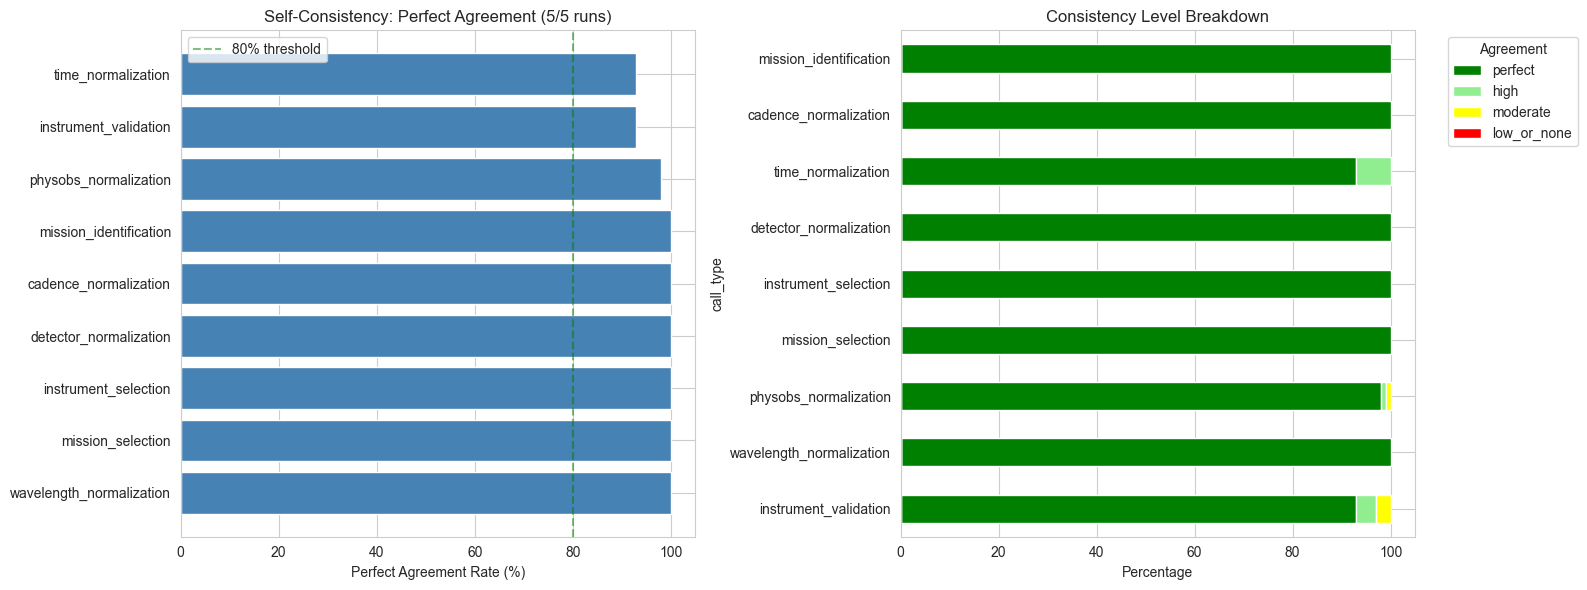

In [ ]:
# Visualize consistency rates
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Perfect consistency rates
perfect_rates = [(ct, results[ct]['perfect']/results[ct]['total']*100) 
                 for ct in CALL_TYPES if results[ct]['total'] > 0]
call_types_sorted, rates = zip(*sorted(perfect_rates, key=lambda x: x[1], reverse=True))

ax1.barh(call_types_sorted, rates, color='steelblue')
ax1.set_xlabel('Perfect Agreement Rate (%)')
ax1.set_title('Self-Consistency: Perfect Agreement (5/5 runs)')
ax1.axvline(x=80, color='green', linestyle='--', alpha=0.5, label='80% threshold')
ax1.legend()

# Plot 2: Consistency breakdown stacked
breakdown = []
for ct in CALL_TYPES:
    r = results[ct]
    if r['total'] > 0:
        breakdown.append({
            'call_type': ct,
            'perfect': r['perfect']/r['total']*100,
            'high': r['high']/r['total']*100,
            'moderate': r['moderate']/r['total']*100,
            'low_or_none': (r['low'] + r['no_consistency'])/r['total']*100
        })

df_breakdown = pd.DataFrame(breakdown)
df_breakdown.set_index('call_type').plot(kind='barh', stacked=True, ax=ax2, 
                                          color=['green', 'lightgreen', 'yellow', 'red'])
ax2.set_xlabel('Percentage')
ax2.set_title('Consistency Level Breakdown')
ax2.legend(title='Agreement', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

## 6. Detailed Investigation

Examine specific disagreement cases.

In [18]:
# Show disagreement examples for problematic call types
problematic = [(ct, results[ct]['perfect']/results[ct]['total']*100) 
               for ct in CALL_TYPES if results[ct]['total'] > 0 and 
               results[ct]['perfect']/results[ct]['total']*100 < 80]

for call_type, perfect_rate in sorted(problematic, key=lambda x: x[1]):
    print("\n" + "="*80)
    print(f"{call_type.upper()} - {perfect_rate:.1f}% perfect agreement")
    print("="*80)
    
    disagreements = results[call_type]['disagreements']
    print(f"Total disagreements: {len(disagreements)}\n")
    
    # Show top 5 most inconsistent cases
    sorted_disagreements = sorted(disagreements, 
                                  key=lambda x: len(x['responses']), 
                                  reverse=True)[:5]
    
    for i, case in enumerate(sorted_disagreements, 1):
        print(f"{i}. Case {str(case['case_id'])[:8]}...")
        print(f"   Unique responses: {len(case['responses'])}")
        for response, count in case['responses'].most_common():
            print(f"   - {count}x: {response[:100]}")
        print()

In [19]:
# Inspect a specific disagreement case in detail
call_type_to_inspect = 'detector_normalization'  # Change this
case_index = 0  # First disagreement case

if results[call_type_to_inspect]['disagreements']:
    case = results[call_type_to_inspect]['disagreements'][case_index]
    case_id = case['case_id']
    
    print(f"\n{'='*80}")
    print(f"DETAILED CASE INSPECTION: {call_type_to_inspect}")
    print(f"Case ID: {case_id}")
    print(f"{'='*80}\n")
    
    # Load the actual data from all runs
    for run in range(1, NUM_RUNS + 1):
        exp_name = f"{call_type_to_inspect}_{TEST_SET_TAG}_run{run}"
        exp_dir = OUTPUT_DIR / exp_name
        jsonl_files = list(exp_dir.glob('*.jsonl'))
        
        if jsonl_files:
            with open(jsonl_files[0]) as f:
                for line in f:
                    data = json.loads(line)
                    if data.get('original_id') == case_id or data.get('case_index') == case_id:
                        print(f"Run {run}:")
                        print(f"  Output: {data.get('output_content', '')[:200]}")
                        print(f"  Parsed: {data.get('parsed_response')}")
                        print()
                        break
else:
    print(f"No disagreements found for {call_type_to_inspect}")

No disagreements found for detector_normalization


## 7. Generate Final Report

Create markdown report for technical documentation.

In [ ]:
# Generate comprehensive report
!cd ../.. && python scripts/generate_self_consistency_report.py

print("\n✅ Report generated: experiments/compare_models/test_set_2025_11_26_self_consistency_report.md")

## Summary

This notebook demonstrated:
1. ✅ Exporting LLM calls from production with render context
2. ✅ Random sampling to avoid temporal bias
3. ✅ Running 5 self-consistency experiments per call type
4. ✅ Analyzing results with Fleiss' kappa and consistency metrics
5. ✅ Investigating disagreement patterns

**Next Steps:**
- Review the generated markdown report
- Investigate low-consistency call types
- Include results in technical report

## 8. Export Publication Figures

Save figures for paper/report with consistent styling.

In [31]:
# Figure export configuration
FIGURE_DIR = Path('../../exports/figures/self_consistency')
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Common settings
FIGURE_DPI = 300
FIGURE_STYLE = 'seaborn-v0_8-whitegrid'

def save_figure(fig, name, dpi=FIGURE_DPI):
    """Save figure in both PNG and PDF formats."""
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    
    fig.savefig(png_path, dpi=dpi, bbox_inches='tight', facecolor='white')
    fig.savefig(pdf_path, bbox_inches='tight', facecolor='white')
    
    print(f"Saved: {png_path.name}, {pdf_path.name}")
    return png_path, pdf_path

# Prepare data for figures
df_viz = pd.DataFrame([
    {
        'task': ct.replace('_', ' ').title(),
        'perfect': results[ct]['perfect'],
        'high': results[ct]['high'],
        'moderate': results[ct]['moderate'],
        'low_none': results[ct]['low'] + results[ct]['no_consistency'],
        'total': results[ct]['total']
    }
    for ct in CALL_TYPES if results[ct]['total'] > 0
])
df_viz['perfect_pct'] = df_viz['perfect'] / df_viz['total'] * 100
df_viz = df_viz.sort_values('perfect_pct', ascending=True)

print(f"Figure output directory: {FIGURE_DIR.absolute()}")

Figure output directory: /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/../../exports/figures/self_consistency


Saved: self_consistency_stacked_breakdown.png, self_consistency_stacked_breakdown.pdf


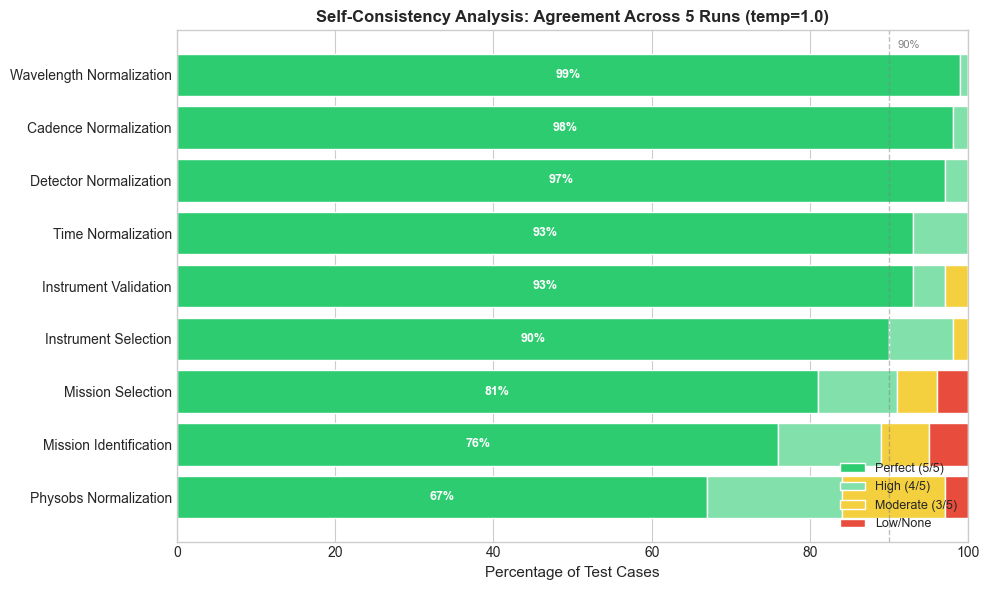

In [32]:
# Figure 1: Stacked horizontal bar chart - Self-consistency breakdown
plt.style.use(FIGURE_STYLE)

fig, ax = plt.subplots(figsize=(10, 6))

# Create stacked bars
tasks = df_viz['task'].values
y_pos = range(len(tasks))

# Calculate percentages
perfect_pct = df_viz['perfect'].values / df_viz['total'].values * 100
high_pct = df_viz['high'].values / df_viz['total'].values * 100
moderate_pct = df_viz['moderate'].values / df_viz['total'].values * 100
low_pct = df_viz['low_none'].values / df_viz['total'].values * 100

# Colors
colors = {
    'perfect': '#2ecc71',    # Green
    'high': '#82e0aa',       # Light green
    'moderate': '#f4d03f',   # Yellow
    'low': '#e74c3c'         # Red
}

# Plot stacked bars
bars1 = ax.barh(y_pos, perfect_pct, label='Perfect (5/5)', color=colors['perfect'])
bars2 = ax.barh(y_pos, high_pct, left=perfect_pct, label='High (4/5)', color=colors['high'])
bars3 = ax.barh(y_pos, moderate_pct, left=perfect_pct+high_pct, label='Moderate (3/5)', color=colors['moderate'])
bars4 = ax.barh(y_pos, low_pct, left=perfect_pct+high_pct+moderate_pct, label='Low/None', color=colors['low'])

# Formatting
ax.set_yticks(y_pos)
ax.set_yticklabels(tasks)
ax.set_xlabel('Percentage of Test Cases', fontsize=11)
ax.set_title('Self-Consistency Analysis: Agreement Across 5 Runs (temp=1.0)', fontsize=12, fontweight='bold')
ax.set_xlim(0, 100)

# Add percentage labels on bars
for i, (p, h, m, l) in enumerate(zip(perfect_pct, high_pct, moderate_pct, low_pct)):
    if p > 10:  # Only label if there's room
        ax.text(p/2, i, f'{p:.0f}%', ha='center', va='center', fontsize=9, fontweight='bold', color='white')

# Legend
ax.legend(loc='lower right', fontsize=9)

# Add vertical line at 90%
ax.axvline(x=90, color='gray', linestyle='--', alpha=0.5, linewidth=1)
ax.text(91, len(tasks)-0.5, '90%', fontsize=8, color='gray')

plt.tight_layout()
save_figure(fig, 'self_consistency_stacked_breakdown')
plt.show()

In [ ]:
# Figure 2: Simple bar chart - Perfect agreement rates only
fig, ax = plt.subplots(figsize=(10, 5))

# Color bars by tier
tier_colors = []
for pct in df_viz['perfect_pct'].values:
    if pct >= 93:
        tier_colors.append('#2ecc71')  # Green - excellent
    elif pct >= 80:
        tier_colors.append('#3498db')  # Blue - strong
    else:
        tier_colors.append('#e67e22')  # Orange - moderate

bars = ax.barh(df_viz['task'], df_viz['perfect_pct'], color=tier_colors)

# Add value labels
for bar, pct in zip(bars, df_viz['perfect_pct']):
    ax.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2, 
            f'{pct:.0f}%', va='center', fontsize=10)

# Formatting
ax.set_xlabel('Perfect Agreement Rate (%)', fontsize=11)
ax.set_title('Self-Consistency: Perfect Agreement (5/5 runs) by Task', fontsize=12, fontweight='bold')
ax.set_xlim(0, 105)

# Add tier threshold lines
ax.axvline(x=93, color='green', linestyle='--', alpha=0.4, linewidth=1)
ax.axvline(x=80, color='blue', linestyle='--', alpha=0.4, linewidth=1)

# Custom legend for tiers
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ecc71', label='Tier 1: Excellent (≥93%)'),
    Patch(facecolor='#3498db', label='Tier 2: Strong (80-92%)'),
    Patch(facecolor='#e67e22', label='Tier 3: Moderate (<80%)')
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
save_figure(fig, 'self_consistency_perfect_agreement')
plt.show()

In [33]:
# List all exported figures
print("Exported figures:")
for f in sorted(FIGURE_DIR.glob('*')):
    print(f"  {f.name}")

print(f"\nFull path: {FIGURE_DIR.absolute()}")
print("\nTo regenerate: Re-run cells 26-28 in this notebook")

Exported figures:
  self_consistency_stacked_breakdown.pdf
  self_consistency_stacked_breakdown.png

Full path: /Users/abuonomo/code/nasa/paper-data-linking/experiments/compare_models/../../exports/figures/self_consistency

To regenerate: Re-run cells 26-28 in this notebook
